# Modeling with DINOv2 embeddings (strict dataset)

This notebook evaluates whether warmth and competence can be predicted from DINOv2 embeddings extracted from the final strict dataset. The modeling setup mirrors the SigLIP experiment so that differences in performance can be attributed to the choice of visual encoder rather than to changes in the data or evaluation protocol.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

## 1. Loading the DINOv2 dataset

The input for this notebook is the strict dataset merged with DINOv2 embeddings. Each row corresponds to one artwork, with the original metadata and target variables together with a set of embedding dimensions (`emb_*`) used as predictors.

In [2]:
DATA_PATH = "../Embeddings/dinov2/final_dataset_strict_with_dinov2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (3060, 789)


,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,NaN,0,1,17th c.,...,-1.047690,-1.745325,3.675401,2.355326,-0.382265,3.596227,1.518095,-0.291360,-2.527206,-1.529001
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,NaN,1,1,16th c.,...,-0.586006,0.992511,1.241005,1.684799,1.214453,5.411584,1.288250,-1.936812,-1.874689,-0.640553


## 2. Defining features and targets

The target variables are the SADCAT-derived warmth and competence scores. The predictors are the DINOv2 embedding dimensions extracted from each artwork image.

In [3]:
y_warmth = df["dirmean_Warmth"]
y_competence = df["dirmean_Competence"]

emb_cols = [col for col in df.columns if col.startswith("emb_")]
X = df[emb_cols]

print("Feature matrix shape:", X.shape)
print("Number of embedding columns:", len(emb_cols))

Feature matrix shape: (3060, 768)
Number of embedding columns: 768


## 3. Train-test split

To make the comparison with the SigLIP experiment fair, the same random split strategy is used here. The data is divided into training and test sets using a fixed random seed.

In [4]:
X_train, X_test, y_w_train, y_w_test = train_test_split(
    X, y_warmth, test_size=0.2, random_state=42
)

_, _, y_c_train, y_c_test = train_test_split(
    X, y_competence, test_size=0.2, random_state=42
)

## 4. Mean baseline

Before fitting predictive models, a constant mean baseline is computed. This provides a minimal reference point for model performance and makes it possible to determine whether the learned models are actually extracting useful signal from the embeddings.

In [5]:
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{name} R²: {r2:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print("-" * 30)

y_w_baseline = np.repeat(y_w_train.mean(), len(y_w_test))
y_c_baseline = np.repeat(y_c_train.mean(), len(y_c_test))

evaluate(y_w_test, y_w_baseline, "Warmth mean baseline")
evaluate(y_c_test, y_c_baseline, "Competence mean baseline")

Warmth mean baseline R²: -0.0015
Warmth mean baseline RMSE: 0.4230
------------------------------
Competence mean baseline R²: -0.0001
Competence mean baseline RMSE: 0.2629
------------------------------


## 5. Linear model: Ridge regression

A Ridge regression model is first fitted to test whether warmth and competence can be recovered through a linear mapping from the DINOv2 embedding space.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_w = Ridge(alpha=1.0)
model_c = Ridge(alpha=1.0)

model_w.fit(X_train_scaled, y_w_train)
model_c.fit(X_train_scaled, y_c_train)

y_w_pred_ridge = model_w.predict(X_test_scaled)
y_c_pred_ridge = model_c.predict(X_test_scaled)

evaluate(y_w_test, y_w_pred_ridge, "Warmth Ridge")
evaluate(y_c_test, y_c_pred_ridge, "Competence Ridge")

Warmth Ridge R²: -0.3444
Warmth Ridge RMSE: 0.4901
------------------------------
Competence Ridge R²: -0.5003
Competence Ridge RMSE: 0.3220
------------------------------


## 6. Non-linear model: Random Forest

Because stereotype-related information may not be linearly recoverable from the embedding space, a Random Forest regressor is also tested. This allows the evaluation of whether more flexible non-linear models can better capture the relationship between visual representations and the target variables.

In [8]:
rf_w = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_c = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_w.fit(X_train, y_w_train)
rf_c.fit(X_train, y_c_train)

y_w_pred_rf = rf_w.predict(X_test)
y_c_pred_rf = rf_c.predict(X_test)

evaluate(y_w_test, y_w_pred_rf, "Warmth RF")
evaluate(y_c_test, y_c_pred_rf, "Competence RF")

Warmth RF R²: 0.0829
Warmth RF RMSE: 0.4048
------------------------------
Competence RF R²: -0.0171
Competence RF RMSE: 0.2651
------------------------------


## 7. Results summary

The table below compares the mean baseline, the linear Ridge model, and the non-linear Random Forest model for both warmth and competence.

In [10]:
results_summary = pd.DataFrame([
    {
        "target": "Warmth",
        "model": "Mean baseline",
        "r2": r2_score(y_w_test, y_w_baseline),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_baseline))
    },
    {
        "target": "Warmth",
        "model": "Ridge",
        "r2": r2_score(y_w_test, y_w_pred_ridge),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_pred_ridge))
    },
    {
        "target": "Warmth",
        "model": "Random Forest",
        "r2": r2_score(y_w_test, y_w_pred_rf),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_pred_rf))
    },
    {
        "target": "Competence",
        "model": "Mean baseline",
        "r2": r2_score(y_c_test, y_c_baseline),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_baseline))
    },
    {
        "target": "Competence",
        "model": "Ridge",
        "r2": r2_score(y_c_test, y_c_pred_ridge),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_pred_ridge))
    },
    {
        "target": "Competence",
        "model": "Random Forest",
        "r2": r2_score(y_c_test, y_c_pred_rf),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_pred_rf))
    }
])

results_summary

,target,model,r2,rmse
0,Warmth,Mean baseline,-0.001500,0.422981
1,Warmth,Ridge,-0.344378,0.490068
2,Warmth,Random Forest,0.082853,0.404776
3,Competence,Mean baseline,-0.000110,0.262894
4,Competence,Ridge,-0.500305,0.321992
5,Competence,Random Forest,-0.017102,0.265117


## 8. Prediction plots

The following plots compare true and predicted values for the Random Forest model. These visualizations make it easier to assess how tightly predictions follow the target values and whether performance differs across the two stereotype dimensions.

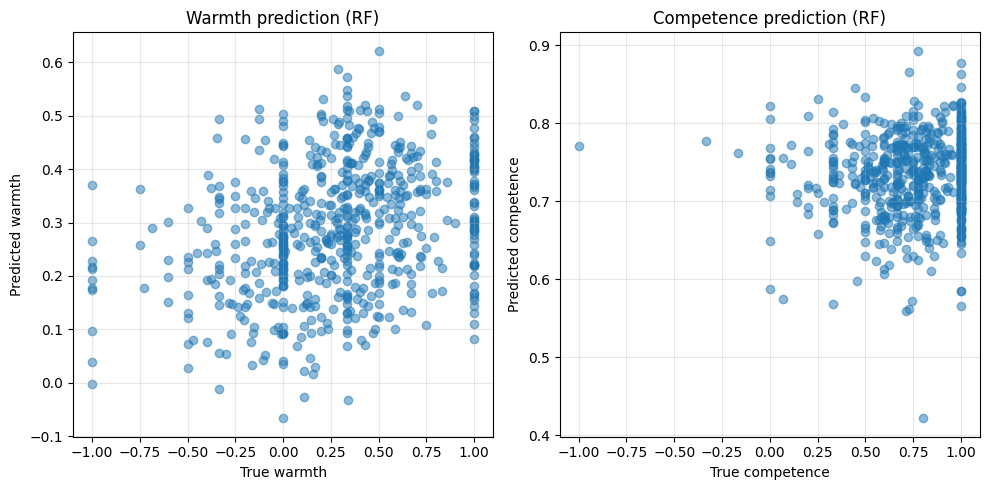

In [11]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_w_test, y_w_pred_rf, alpha=0.5)
plt.xlabel("True warmth")
plt.ylabel("Predicted warmth")
plt.title("Warmth prediction (RF)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_c_test, y_c_pred_rf, alpha=0.5)
plt.xlabel("True competence")
plt.ylabel("Predicted competence")
plt.title("Competence prediction (RF)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation of DINOv2 modeling results

The results obtained using DINOv2 embeddings show a clear pattern that closely mirrors, but slightly underperforms, the SigLIP-based models.

For warmth, the Random Forest model achieves a small positive R² (≈ 0.083), indicating that a limited amount of predictive signal can be extracted from the visual embeddings. However, performance remains relatively weak, and the improvement over the mean baseline is modest. The Ridge model performs substantially worse than the baseline, suggesting that the relationship between DINOv2 embeddings and warmth is not well captured by a linear mapping.

For competence, performance is even more constrained. Both Ridge and Random Forest models fail to outperform the baseline, with R² values that are negative or close to zero. This confirms that competence is particularly difficult to predict from visual features alone in this dataset.

The prediction plots reinforce these findings. For warmth, there is a weak positive trend, but predictions remain highly compressed toward the center of the distribution. For competence, predictions are tightly clustered around high values, reflecting the strong ceiling effect observed during the exploratory analysis.

Overall, these results suggest that:
- DINOv2 embeddings contain some limited information related to warmth  
- Competence is not meaningfully recoverable from visual features alone  
- Non-linear models (Random Forest) are better suited than linear models for this task  
- The predictive signal remains weak, indicating that stereotype-related dimensions are only partially encoded in visual representations  

## Comparison: SigLIP vs DINOv2

Comparing the two embedding approaches reveals consistent but informative differences.

For warmth, both models achieve small positive R² values when using Random Forest, indicating that some visual signal is present. However, SigLIP performs slightly better than DINOv2, suggesting that vision-language models may capture higher-level semantic features that are more aligned with stereotype-related dimensions.

For competence, neither embedding approach produces meaningful predictive performance. Both models struggle due to the strong ceiling effect in the target distribution, which limits variability and makes learning difficult regardless of the encoder used.

A key difference emerges in the linear models: Ridge regression performs poorly for both encoders, but particularly poorly for DINOv2. This suggests that the relationship between embeddings and targets is not linearly separable, and that any signal present is encoded in a more complex, non-linear way.

Overall, the comparison indicates that:
- SigLIP slightly outperforms DINOv2, particularly for warmth  
- Both models fail on competence due to target distribution issues  
- Non-linear models consistently outperform linear ones  
- The main limitation is not only the encoder, but the structure of the labels themselves  

This supports the idea that stereotype-related dimensions are only weakly reflected in visual embeddings and are heavily influenced by textual descriptions and contextual interpretation.